# Problem Solution Pipeline

## Data Preparation
We utilize DuckDB to interface directly with our processed relational database. This demonstrates how Python interacts with DuckDB to query structured data efficiently without loading the entire raw dataset into memory.

In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Connect to the persistent DuckDB database created during the ingestion phase
con = duckdb.connect('faers_ml.duckdb')

print("Connected to DuckDB successfully.")
print(con.execute("SHOW TABLES").df())

Connected to DuckDB successfully.
        name
0      drugs
1   outcomes
2   patients
3  reactions
4    reports


## Query: Preparing the Solution
Here we execute a Common Table Expression (CTE) query to join the reports, patients, drugs, and outcomes tables. This generates mathematically sound clinical proxies, such as polypharmacy burden, while extracting the severe_outcome target variable for modeling.

In [2]:
# Define the regex pattern for our clinical prior (High-Risk Drugs)
HIGH_RISK_PATTERN = 'ADALIMUMAB|AMIODARONE|APIXABAN|ASPIRIN|BENDROFLUMETHIAZIDE|BUMETANIDE|CAPTOPRIL|CELECOXIB|CLOZAPINE|DABIGATRAN|DICLOFENAC|DIGOXIN|DIPYRIDAMOLE|ENALAPRIL|FENTANYL|FLUOXETINE|FUROSEMIDE|HYDROCODONE|IBUPROFEN|INSULIN|KETOPROFEN|LENALIDOMIDE|LITHIUM|MELOXICAM|METHOTREXATE|MORPHINE|OXYCODONE|PAROXETINE|PREDNISOLONE|RAMIPRIL|RIVAROXABAN|ROFECOXIB|SERTRALINE|SPIRONOLACTONE|TRAMADOL|VALPROATE|WARFARIN'

# Execute the feature engineering query directly via DuckDB
query = f"""
WITH clean_patients AS (
    SELECT 
        report_id, 
        MAX(TRY_CAST(patient_age AS FLOAT)) AS patient_age, 
        MAX(patient_sex) AS patient_sex
    FROM patients
    WHERE patient_age IS NOT NULL AND patient_sex IS NOT NULL
      AND TRY_CAST(patient_age AS FLOAT) BETWEEN 0 AND 120
    GROUP BY report_id
    HAVING COUNT(DISTINCT patient_sex) = 1
),
drug_burden AS (
    SELECT 
        report_id,
        COUNT(DISTINCT drug_name) AS polypharmacy_count,
        SUM(CASE WHEN role_cod = 'PS' THEN 1 ELSE 0 END) AS primary_suspect_count,
        MAX(CASE 
            WHEN REGEXP_MATCHES(UPPER(COALESCE(drug_name, '')), '{HIGH_RISK_PATTERN}') 
            THEN 1 ELSE 0 
        END) AS is_high_risk_drug
    FROM drugs
    GROUP BY report_id
)
SELECT 
    r.report_id,
    r.reporter_type,
    c.patient_age,
    c.patient_sex,
    EXTRACT(YEAR FROM r.receive_date) AS report_year,
    COALESCE(d.polypharmacy_count, 0) AS polypharmacy_count,
    COALESCE(d.primary_suspect_count, 0) AS primary_suspect_count,
    COALESCE(d.is_high_risk_drug, 0) AS is_high_risk_drug,
    MAX(CASE WHEN o.outcome_code IN ('DE', 'LT', 'HO') THEN 1 ELSE 0 END) AS severe_outcome
FROM reports r
INNER JOIN clean_patients c ON r.report_id = c.report_id
LEFT JOIN drug_burden d ON r.report_id = d.report_id
LEFT JOIN outcomes o ON r.report_id = o.report_id
GROUP BY 
    r.report_id, c.patient_age, c.patient_sex, r.receive_date, r.reporter_type, 
    d.polypharmacy_count, d.primary_suspect_count, d.is_high_risk_drug;
"""

df = con.execute(query).fetchdf()

# Binarize sex (1 = Male, 0 = Female, -1 = Missing)
df['is_male'] = df['patient_sex'].map({'1': 1, 'M': 1, '2': 0, 'F': 0}).fillna(-1).astype('int8')

# Define the Master Feature Set (Explicitly excluding reporter_type to prevent confounding)
feature_cols = [
    'patient_age', 
    'is_male', 
    'polypharmacy_count', 
    'primary_suspect_count', 
    'is_high_risk_drug',
    'report_year',
    'reporter_type'
]

X = df[feature_cols]
y = df['severe_outcome']

print(f"Dataset ready: {len(df):,} records loaded from DuckDB.")

Dataset ready: 2,339,316 records loaded from DuckDB.


## Solution Analysis: Model Implementation
**Analysis Rationale:** The model’s objective is to predict rare, severe clinical outcomes by identifying non-linear risk thresholds within a patient's demographic profile and polypharmacy burden. A Random Forest was explicitly selected because its decision-tree architecture naturally captures the exponential, compounded risks of drug interactions without requiring manual mathematical transformations. To ensure clinical reliability against a dataset overwhelmingly biased toward non-serious reports, the design incorporates stratify=y for balanced sampling, balanced_subsample to heavily penalize missed signals at the tree level, and optimizes for average_precision to maximize the capture of true severe cases while minimizing false alarms.

In [3]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, 
    average_precision_score, 
    roc_auc_score, 
    PrecisionRecallDisplay
)
import pandas as pd
import matplotlib.pyplot as plt

if len(X) > 500:
    # 1. Stratified Split (80/20)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # 2. Configure the Bootstrapped Forest
    # We use 'max_samples' to limit each tree to a fraction of the data.
    # This makes training significantly faster on 460k+ rows.
    rf_fast = RandomForestClassifier(
        bootstrap=True, 
        max_samples=0.2, # Each tree only sees 20% of the data (Bootstrap Subsampling)
        class_weight='balanced_subsample', # Weights updated per bootstrap
        random_state=42,
        n_jobs=-1
    )
    
    # 3. Randomized Search (Much faster than Grid Search)
    param_dist = {
        'n_estimators': [100, 200],
        'max_depth': [10, 15, 20],
        'min_samples_leaf': [2, 5, 10],
        'max_features': ['sqrt', 'log2']
    }
    
    search = RandomizedSearchCV(
        rf_fast, 
        param_distributions=param_dist, 
        n_iter=8, # Only 8 combinations to save time
        cv=3, 
        scoring='average_precision', 
        verbose=1
    )
    
    search.fit(X_train, y_train)
    best_rf = search.best_estimator_
    
    # 4. Predictions
    y_prob = best_rf.predict_proba(X_test)[:, 1]
    y_pred = best_rf.predict(X_test)
    
    print(f"--- 10-Year Universal Triage (Random Forest) ---")
    print(f"PR-AUC: {average_precision_score(y_test, y_prob):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # 5. Native Feature Importance
    # Random Forest allows us to see exactly which feature "split" the most danger.
    importances = pd.Series(
        best_rf.feature_importances_, index=X.columns
    ).sort_values(ascending=False)
    
    print("\nFeature Importance (Gini Impurity):")
    print(importances)

else:
    print("Insufficient data.")

Fitting 3 folds for each of 8 candidates, totalling 24 fits
--- 10-Year Universal Triage (Random Forest) ---
PR-AUC: 0.5709

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.69      0.74    310791
           1       0.51      0.64      0.57    157073

    accuracy                           0.67    467864
   macro avg       0.65      0.67      0.65    467864
weighted avg       0.70      0.67      0.68    467864


Feature Importance (Gini Impurity):
polypharmacy_count       0.259125
patient_age              0.222685
reporter_type            0.193294
report_year              0.107057
primary_suspect_count    0.099586
is_high_risk_drug        0.074321
is_male                  0.043932
dtype: float64


## Visualize Results
**Visualization Rationale:** I used a Precision-Recall (PR) curve instead of a standard ROC curve because our clinical dataset is highly imbalanced. In datasets where severe events are more rare, ROC curves can be misleading because the huge number of minor cases artificially inflates the model's overall score. By using a PR curve compared against the baseline incidence rate, we get a much more accurate picture of how well the model actually catches rare, severe events without triggering too many false medical alarms.

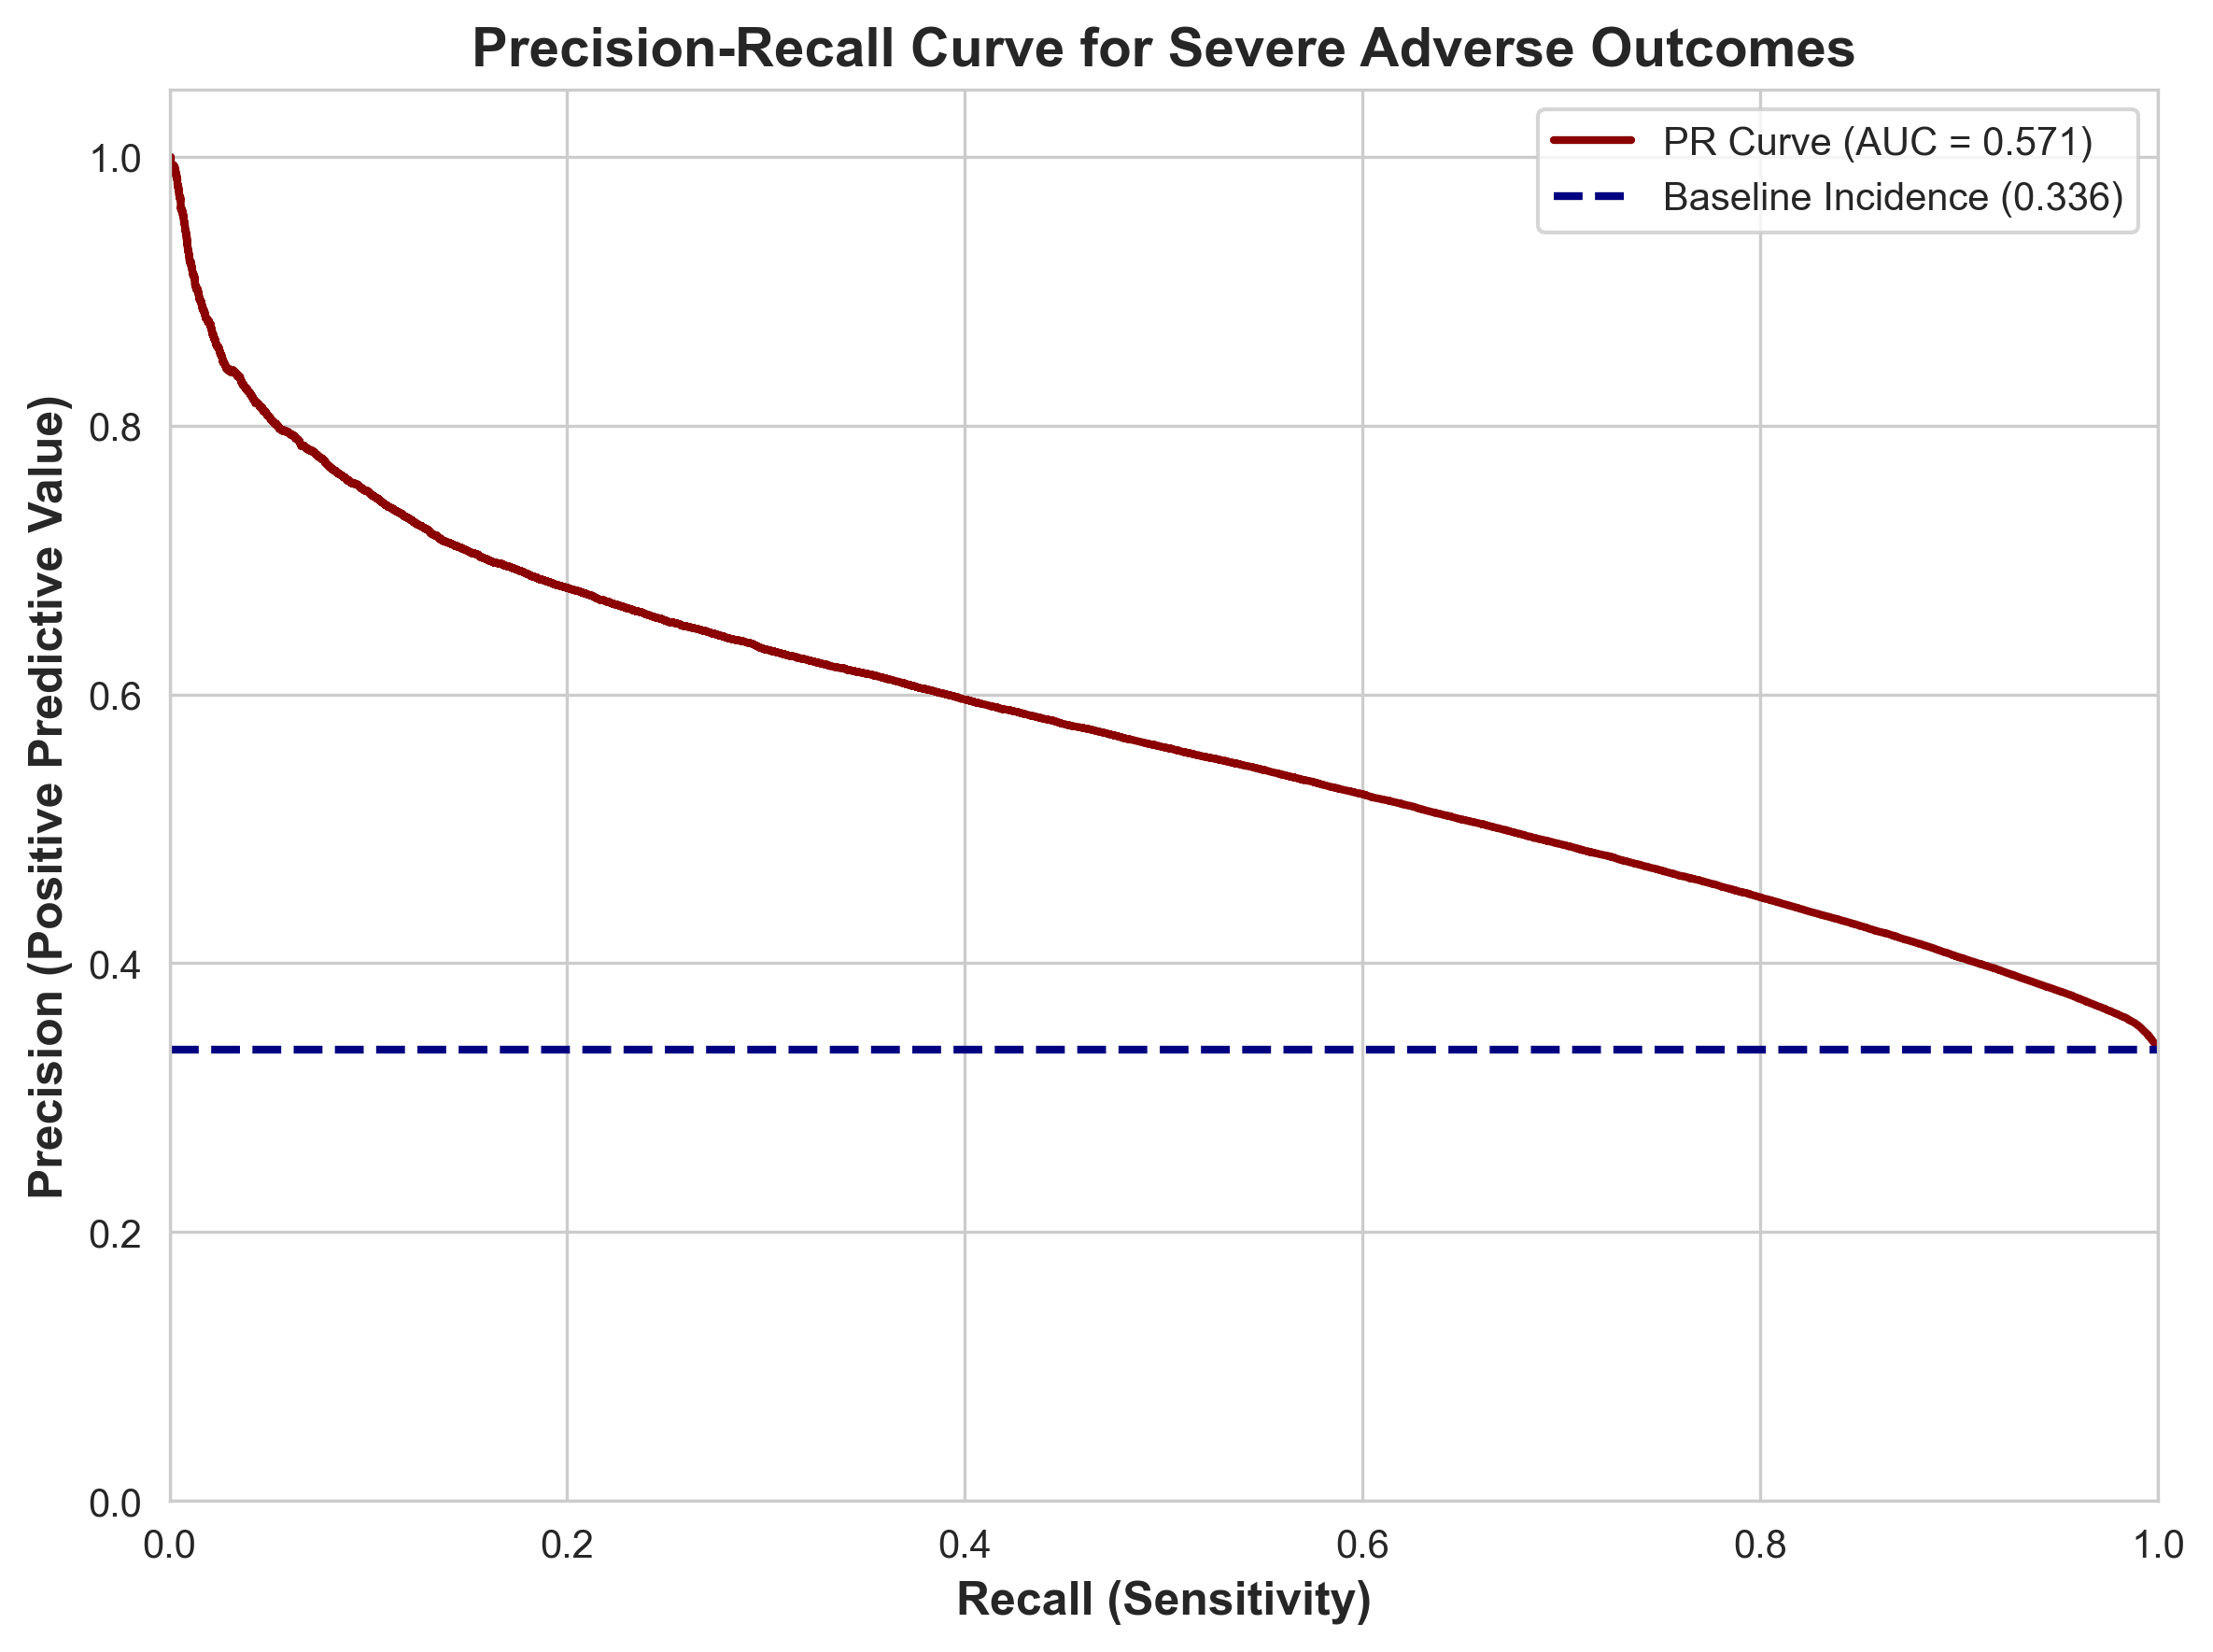

In [5]:
from sklearn.metrics import precision_recall_curve, auc


if len(X) > 100:
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(recall, precision)
    baseline = y_test.sum() / len(y_test)
    
    plt.figure(figsize=(8, 6), dpi=300)
    sns.set_style("whitegrid")
    
    plt.plot(recall, precision, color='darkred', lw=2, label=f'PR Curve (AUC = {pr_auc:.3f})')
    plt.axhline(y=baseline, color='navy', lw=2, linestyle='--', label=f'Baseline Incidence ({baseline:.3f})')
    
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Recall (Sensitivity)', fontsize=12, fontweight='bold')
    plt.ylabel('Precision (Positive Predictive Value)', fontsize=12, fontweight='bold')
    plt.title('Precision-Recall Curve for Severe Adverse Outcomes', fontsize=14, fontweight='bold')
    plt.legend(loc="upper right")
    plt.tight_layout()
    
    plt.savefig('./images/pr_curve.png') 
    plt.show()